In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings("ignore")

In [40]:
df = pd.read_excel("Online Retail.xlsx")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (65535, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55   17,850.00  United Kingdom  
1 2010-12-01 08:26:00       3.39   17,850.00  United Kingdom  
2 2010-12-01 08:26:00       2.75   17,850.00  United Kingdom  
3 2010-12-01 08:26:00       3.39   17,850.00  United Kingdom  
4 2010-12-01 08:26:00       3.39   17,850.00  United Kingdom  


In [41]:
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['CustomerID'] = df['CustomerID'].astype(int)

In [42]:
print("Total Customers:", df['CustomerID'].nunique())
print("Total Revenue:", df['TotalPrice'].sum())

Total Customers: 1139
Total Revenue: 983149.8300000001


In [43]:
# Modify column names: lower case characters and replace white space " " with an underscore "_"
df.columns = [col.lower() for col in df.columns]
df.columns = [col.replace(' ', '_') for col in df.columns]

In [44]:
# Format customer_id by adding zeros and removing digits where required
# Keep in mind that the customer_id's last digits are unique (at max the last four digits)
def clean_customer_id(customer_id):
    customer_id_str = str(customer_id) # Convert to string to prevent TypeError with re.split
    # The original regex r"[-][\n]" caused a SyntaxError due to the literal newline.
    # It has been corrected to split by a single hyphen '-'.
    modify_customer_id = re.split(r"-", customer_id_str)

    # The following logic assumes customer_id_str contains a hyphen,
    # meaning len(modify_customer_id) will be at least 2.
    # If customer_id_str does not contain a hyphen (e.g., '17850'),
    # then modify_customer_id will be ['17850'], and attempting to access
    # modify_customer_id[1] will cause an IndexError.
    # For now, to prevent an immediate IndexError, we return the original string
    # if no hyphen is found. You will need to modify this function to handle cases
    # where customer IDs do not contain a hyphen based on your requirements.
    if len(modify_customer_id) < 2:
        return customer_id_str

    if(len(modify_customer_id[1]) < 3):
        two_zero_padding = modify_customer_id[0] + '-' + modify_customer_id[1].rjust(2+len(modify_customer_id[1]), '0')
        return two_zero_padding
    elif(len(modify_customer_id[1]) < 4):
        one_zero_padding =  modify_customer_id[0] + '-' + modify_customer_id[1].rjust(1+len(modify_customer_id[1]), '0')
        return one_zero_padding
    elif(len(modify_customer_id[1]) == 4):
        none_zero_padding =  modify_customer_id[0] + '-' + modify_customer_id[1]
        return none_zero_padding
    elif(len(modify_customer_id[1]) == 5):
        shorten_to_four_digits =  modify_customer_id[0] + '-' + modify_customer_id[1][1:]
        return shorten_to_four_digits

# Apply clean_customer_id function and update column
df['customerid'] = df['customerid'].apply(clean_customer_id)

In [45]:
# Change date format: changes dates in the form of (d-m-Y) to (m/d/Y)
def clean_dates(dates):
    if(re.search('\-.*', dates)):
        date_split = re.split(r'[-]',dates)
        clean_date = date_split[1].lstrip('0') + '/' + date_split[0] + '/'+date_split[2]
        return clean_date
    else:
        return dates

# The KeyError 'order_date' occurs because 'order_date' and 'ship_date' columns do not exist.
# The existing date column is 'invoicedate', which is already a datetime object.
# The 'clean_dates' function is designed for specific string formats (d-m-Y) that don't match 'invoicedate'.
# Thus, applying 'clean_dates' to 'invoicedate' (which is datetime) would also lead to errors or unexpected results.

# If the intention was to work with 'invoicedate', it is already a datetime object and no further cleaning/conversion as per this cell's logic is needed.
# If new 'order_date' or 'ship_date' columns are to be created from 'invoicedate', they should be explicitly defined first.

# Commenting out the problematic lines to resolve the KeyError and prevent type mismatches.
# df['order_date'] = df['order_date'].apply(clean_dates)
# df['ship_date'] = df['ship_date'].apply(clean_dates)

# Changes dates to datetime (redundant for 'invoicedate' as it's already datetime)
# df['order_date'] = pd.to_datetime(df['order_date'])
# df['ship_date'] = pd.to_datetime(df['ship_date'])


In [46]:
# Removes duplicates
df = df.drop_duplicates()

In [47]:
# Check min and max dates of column 'invoicedate'
print('Oldest date for invoicedate column: ' + str(df['invoicedate'].min()))
print('Most recent date for invoicedate column: ' + str(df['invoicedate'].max()))

Oldest date for invoicedate column: 2010-12-01 08:26:00
Most recent date for invoicedate column: 2011-01-20 16:17:00


In [48]:
# Grouping and Aggregating the data: Group data by customerid and aggregate invoiceno by counting, invoicedate by the max date and totalprice by the sum of totalprice
agg_dict = {'invoiceno': 'count', 'invoicedate': 'max', 'totalprice': 'sum'}
df_rfm = df.groupby('customerid').agg(agg_dict).reset_index()
df_rfm.columns = ['customerid', 'frequency', 'most_recent_order', 'monetary'] #column labels
df_rfm.head()

,customerid,frequency,most_recent_order,monetary
0,12346,1,2011-01-18 10:01:00,"77,183.60"
1,12347,31,2010-12-07 14:57:00,711.79
2,12348,17,2010-12-16 19:09:00,892.80
3,12356,36,2011-01-18 09:50:00,"2,271.62"
4,12359,16,2011-01-12 12:43:00,547.50


In [49]:
df_rfm['recency'] =  (df_rfm['most_recent_order'] - df["invoicedate"].min()).dt.days
df_rfm.head()

,customerid,frequency,most_recent_order,monetary,recency
0,12346,1,2011-01-18 10:01:00,"77,183.60",48
1,12347,31,2010-12-07 14:57:00,711.79,6
2,12348,17,2010-12-16 19:09:00,892.80,15
3,12356,36,2011-01-18 09:50:00,"2,271.62",48
4,12359,16,2011-01-12 12:43:00,547.50,42


In [50]:
# Join all the data needed
df_rfm = df_rfm[['customerid', 'recency', 'frequency', 'monetary']]
df_rfm.head()

,customerid,recency,frequency,monetary
0,12346,48,1,"77,183.60"
1,12347,6,31,711.79
2,12348,15,17,892.80
3,12356,48,36,"2,271.62"
4,12359,42,16,547.50


recency: 


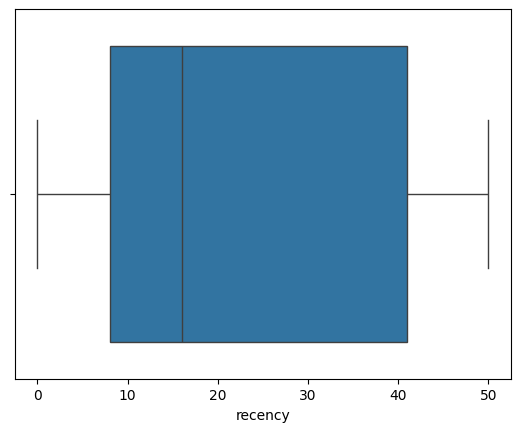

frequency: 


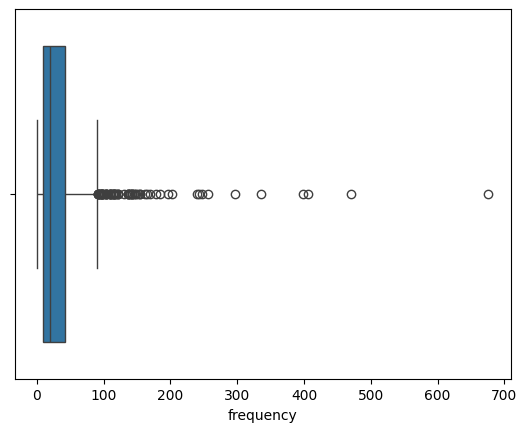

monetary: 


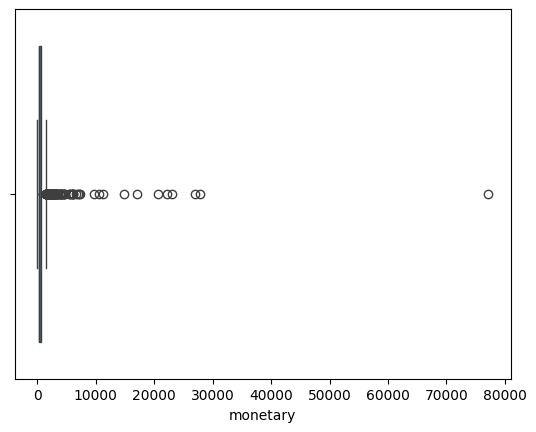

In [51]:
# Plot to visualize outliers: all three have outliers that need to be removed.
rfm_list = ['recency','frequency','monetary']
for i in rfm_list:
    print(str(i)+': ')
    ax = sns.boxplot(x = df_rfm[str(i)])
    plt.show()

In [52]:
from scipy import stats
import numpy as np

In [53]:
# ---Remove outliers---
# Keep data 3 standard deviations from the mean, remove the rest
df_rfm_updated = df_rfm[['recency','frequency','monetary']]
z_scores = stats.zscore(df_rfm_updated )
abs_z_scores = np.abs(z_scores)
filtered_entries = (abs_z_scores < 3 ).all(axis=1)
df_rfm_updated  = df_rfm_updated [filtered_entries]

recency: 


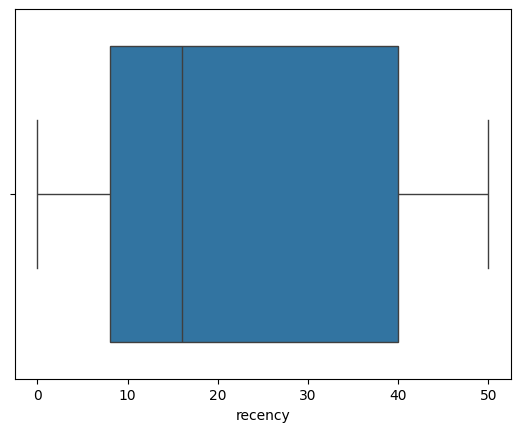

frequency: 


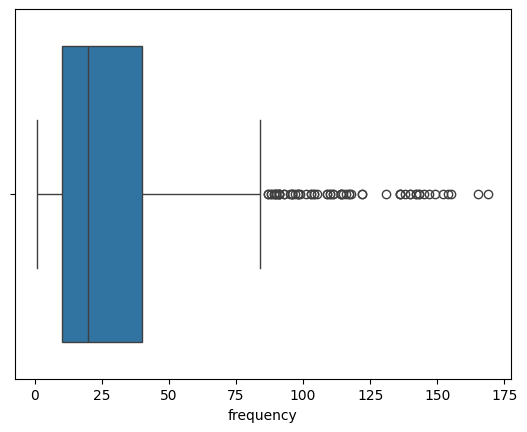

monetary: 


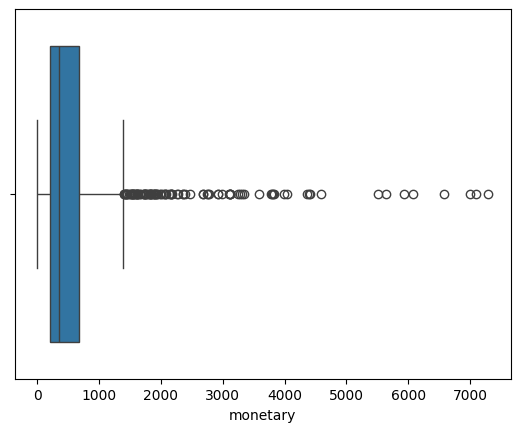

In [54]:
# Plot to visualize removal of outliers: outliers 3 standard deviations from the mean were removed
rfm_list = ['recency','frequency','monetary']
for i in rfm_list:
    print(str(i)+': ')
    ax = sns.boxplot(x = df_rfm_updated[str(i)])
    plt.show()

In [55]:
# ---Standardization of Values---
col_names = ['recency', 'frequency', 'monetary']
z_scores = stats.zscore(df_rfm_updated)
standardized_df = pd.DataFrame(z_scores, columns=col_names)

In [56]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [57]:
SSE = [] # SSE (sum of the squared error) list holds the values for each k
for cluster in range(1,11):
    kmeans = KMeans(n_clusters = cluster, init = 'k-means++') # Number of clusters to form as well as the number of centroids
    kmeans.fit(standardized_df) # Compute k-means clustering on data
    SSE.append(kmeans.inertia_) # Sum of squared distances of samples to their closest cluster center

Text(0, 0.5, 'Sum of Squared Distances')

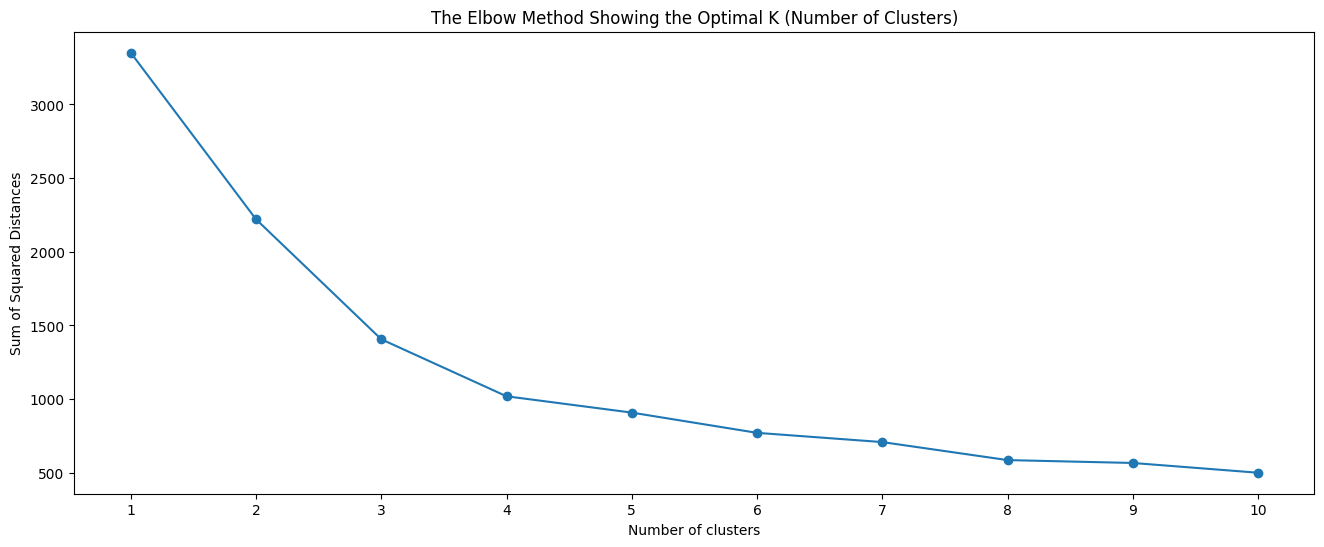

In [58]:
# ---Visualize Elbow Method---
frame = pd.DataFrame({'Cluster': range(1,11), 'SSE': SSE}) # converting the results into a dataframe and plotting them
plt.figure(figsize = (16,6))
plt.plot(frame['Cluster'], frame['SSE'], marker = 'o')
plt.title('The Elbow Method Showing the Optimal K (Number of Clusters)')
plt.xlabel('Number of clusters')
plt.xticks([1,2,3,4,5,6,7,8,9,10])
plt.ylabel('Sum of Squared Distances')

In [59]:
!pip install kneed
from kneed import KneeLocator

In [60]:
# To verify and confirm the "Elbow" of the graph is 3, KneeLocator is used
kl = KneeLocator(
    range(1, 11), SSE, curve = 'convex', direction = 'decreasing'
)
print("Optimal K(Number of Clusters): " + str(kl.elbow) + " clusters")

Optimal K(Number of Clusters): 4 clusters


In [61]:
# Build a model with 3 clusters
kmeans = KMeans(n_clusters = 3, init = 'k-means++')
kmeans.fit(standardized_df)

KMeans(n_clusters=3)

In [62]:
# ---Silhouette Score---
print('The Silhouette Score is ' + str(silhouette_score(standardized_df, kmeans.labels_, metric = 'euclidean')))

The Silhouette Score is 0.4847227921882739


In [63]:
# ---Segmentation Model---
pred = kmeans.predict(standardized_df) # Predict the closest cluster each sample belongs to
frame = pd.DataFrame(df_rfm_updated)
frame['cluster'] = pred

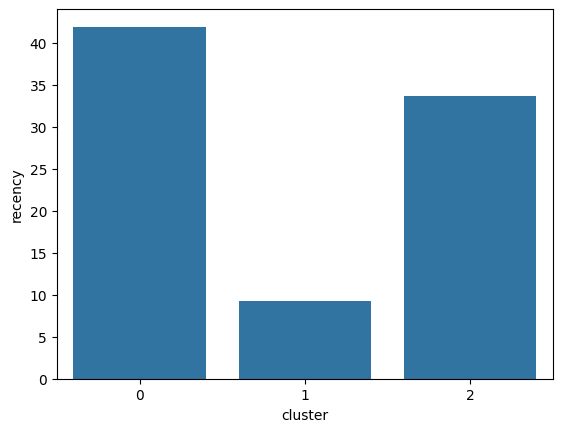

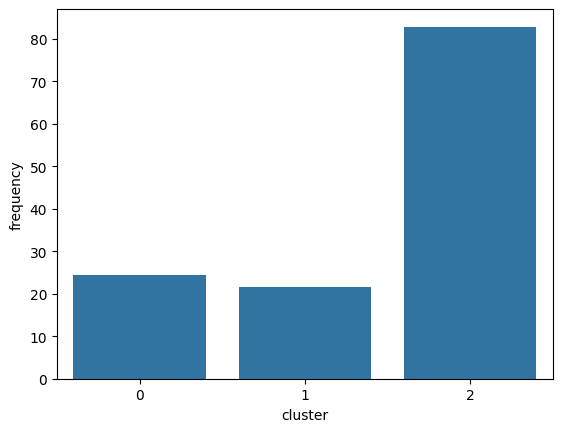

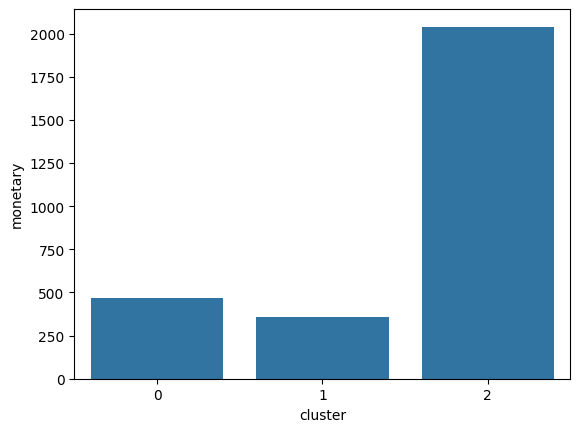

In [65]:
avg_df = frame.groupby(['cluster'], as_index = False).mean()
for i in rfm_list :
    sns.barplot(x = 'cluster', y = str(i), data = avg_df)
    plt.show()

In [67]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [68]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

In [69]:
features = rfm[["Recency", "Frequency", "Monetary"]]

In [71]:
# Define segments based on cluster characteristics derived from avg_df:
# Cluster 2: Highest frequency and monetary -> "Best Customers"
# Cluster 0: Highest recency (meaning not recent) -> "At Risk"
# Cluster 1: Lowest recency, moderate frequency/monetary -> "Loyal"

def assign_customer_segment(row):
    if row['cluster'] == 2:
        return "Best Customers"
    elif row['cluster'] == 0:
        return "At Risk"
    elif row['cluster'] == 1:
        return "Loyal"
    else:
        return "Other" # Fallback for any unexpected cluster values

frame['customer_segment'] = frame.apply(assign_customer_segment, axis=1)

# Display a sample of the segmented data
print("Sample of segmented data:")
print(frame[['recency', 'frequency', 'monetary', 'cluster', 'customer_segment']].head())

# Optionally, display the segment distribution
print("\nCustomer Segment Distribution:")
print(frame['customer_segment'].value_counts())

Sample of segmented data:
   recency  frequency  monetary  cluster customer_segment
1        6         31    711.79        1            Loyal
2       15         17    892.80        1            Loyal
3       48         36  2,271.62        2   Best Customers
4       42         16    547.50        0          At Risk
5       16         90  1,864.27        2   Best Customers

Customer Segment Distribution:
customer_segment
Loyal             610
At Risk           367
Best Customers    140
Name: count, dtype: int64


In [75]:
# Define segmentation function (ensures all categories appear clearly)
def segment_customer(row):
    if (row["Recency"] <= rfm_clean["Recency"].median() and
        row["Frequency"] >= rfm_clean["Frequency"].median() and
        row["Monetary"] >= rfm_clean["Monetary"].median()):
        return "Best Customers"

    elif (row["Frequency"] >= rfm_clean["Frequency"].median() and
          row["Monetary"] >= rfm_clean["Monetary"].median()):
        return "Loyal Customers"

    elif row["Recency"] > rfm_clean["Recency"].median():
        return "At Risk Customers"

    else:
        return "Regular Customers"


# Apply segmentation
rfm_clean["CustomerSegment"] = rfm_clean.apply(segment_customer, axis=1)

In [76]:
import matplotlib.pyplot as plt

# Define all segments explicitly
all_segments = ["Best Customers", "Loyal Customers", "Regular Customers", "At Risk Customers"]

# Count and reindex (ensures all appear)
segment_counts = rfm_clean["CustomerSegment"].value_counts().reindex(all_segments, fill_value=0)

print(segment_counts)

CustomerSegment
Best Customers       293
Loyal Customers      186
Regular Customers    210
At Risk Customers    268
Name: count, dtype: int64


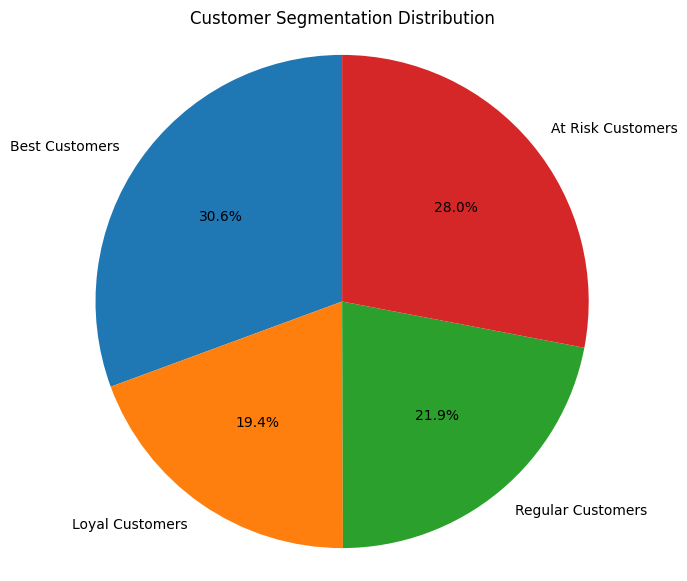

In [77]:
plt.figure(figsize=(7,7))

plt.pie(segment_counts,
        labels=segment_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Customer Segmentation Distribution")
plt.axis('equal')

plt.show()

In [78]:
def check_customer_behavior(customer_id):
    customer_id = int(customer_id)

    customer = rfm_clean[rfm_clean["CustomerID"] == customer_id]

    if customer.empty:
        print("Customer ID not found.")
        return

    recency = customer["Recency"].values[0]
    frequency = customer["Frequency"].values[0]
    monetary = customer["Monetary"].values[0]
    segment = customer["CustomerSegment"].values[0]

    print("Customer Behaviour Report")
    print("--------------------------")
    print("Customer ID:", customer_id)
    print("Recency:", recency, "days since last purchase")
    print("Frequency:", frequency, "orders")
    print("Monetary:", round(monetary, 2), "total spend")
    print("Segment:", segment)

    print("\nBusiness Interpretation:")

    if segment == "Best Customers":
        print("This customer buys recently, buys often, and spends more.")
        print("Action: Give loyalty rewards, premium offers, and early access discounts.")

    elif segment == "Loyal Customers":
        print("This customer purchases frequently and is valuable.")
        print("Action: Send repeat purchase offers and membership benefits.")

    elif segment == "At Risk Customers":
        print("This customer has not purchased recently.")
        print("Action: Send win-back offers, discounts, or reminder emails.")

    elif segment == "Regular Customers":
        print("This customer has average buying behaviour.")
        print("Action: Send product recommendations and normal promotional offers.")

In [80]:
customer_id = input("Enter Customer ID: ")
check_customer_behavior(customer_id)

Enter Customer ID: 13047
Customer Behaviour Report
--------------------------
Customer ID: 13047
Recency: 51 days since last purchase
Frequency: 3 orders
Monetary: 366.63 total spend
Segment: Loyal Customers

Business Interpretation:
This customer purchases frequently and is valuable.
Action: Send repeat purchase offers and membership benefits.
